# 一、前言

 VAE 里已经用过内置的 MNIST + DataLoader，所以真正的新知识点是写自己的 Dataset 子类——这是后面做单细胞数据（GEO/TCGA 下载的表格、AnnData）绕不开的能力。通过手抄一遍例程代码并理解对应的板块步骤和语句作用，最后再小结

# 二、代码

## 1.导入 + 设置

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.13.0+cu126 | device: cuda


要点：
- Dataset 是抽象基类，DataLoader 是取数据的迭代器——两者是组合关系，不是继承关系。只继承 Dataset，DataLoader 永远用现成的。
- torchvision.datasets 里的 MNIST 等已经是 Dataset 子类，所以才能直接丢给 DataLoader。要学的就是它内部怎么实现的。

## 2.手写第一个自定义 Dataset（包装 MNIST）

In [5]:
class MyMNIST(Dataset):
    """把内置 MNIST 包成自定义 Dataset，理解 __len__ 和 __getitem__ 的契约"""
    def __init__(self, root = './data', train = True, transform = None):
        # 直接复用内置数据集，但包一层——展示"组合"思路
        self.data = datasets.MNIST(root = root, train = train, download = True)
        self.transform = transform

    def __len__(self):
        # DataLoader 靠它知道"一共多少样本"
        return len(self.data)

    def __getitem__(self,idx):
        # DataLoader 靠它取"第 idx 个样本"，必须返回 (输入, 标签)
        img, label = self.data[idx]
        if self.transform:    # 判断：如果传入了 transform 工具，就对图像做变换
            img = self.transform(img)
        return img, label

# 实例化
train_ds = MyMNIST(transform = transforms.ToTensor())    # PIL 图片 (H,W) →张量 (C, H, W)，像素值 0‑255 归一到 [0, 1]
print(f'样本数：{len(train_ds)}')
img, label = train_ds[0]   # 直接下标访问
print(f'取第0个样本：形状{img.shape}, 标签 {label}')

样本数：60000
取第0个样本：形状torch.Size([1, 28, 28]), 标签 5


要点（为什么必须实现这两个方法）：
- __len__ + __getitem__ 是 Python 序列协议，DataLoader 内部就靠 len(ds) 和 ds[i] 工作。少写一个，DataLoader 直接报错——这是接口契约，不是可选。
- 返回值必须是 (输入, 标签) 元组，DataLoader 会把它自动拼成 batch 维度（shape 从 (1,28,28) 变 (N,1,28,28)）。
- 注意 __getitem__ 里做 transform——每个样本单独做，不是整个数据集一次做完。这保证数据增强等操作能随机化；如果你的 transform 有随机性（翻转/裁剪），放这里才对，放外面就退化成"每 epoch 同一份增强"。
- 不这么写的后果：直接 transform=... 传给 datasets.MNIST 也能跑，但你学不到"怎么处理自己的数据"。真实场景（读 CSV/AnnData/文件夹图片）没有现成 Dataset 可用，只能自己写。

- `root='./data'`：MNIST 原始文件存放文件夹
- `train=True`：加载训练集；`train=False` →测试集
- `download=True`：本地没有数据集就自动下载
- `self.data`：保存一个**官方 MNIST 数据集实例**
- `self.transform`：图像变换操作（转张量、归一化、增强），默认`None`不做变换

if self.transform:
    img = self.transform(img)
- 在 transform = transforms.Compose([...]) 这儿**仅仅是创建一条「加工流水线蓝图 / 工具对象」，它没有处理任何一张图片**，没有执行变换。
- `self.transform = transform` 只是把这个工具保存起来，只是一个赋值操作！只是把流水线工具的引用存起来，**图片变换依旧一次都没跑过！原始 PIL 图像仍然还是 PIL 图像**
- img = self.transform(img) 才是**拿起这条流水线，真正对当前这一张图片运行全部预处理操作**

## 3.DataLoader 批量化

In [9]:
train_loader = DataLoader(
    train_ds,            # 数据源，传入自定义 Dataset 实例
    batch_size = 64,
    shuffle = True,      # 训练必须打乱，否则每个 epoch 内类别顺序固定，模型学到"顺序"而非"特征"
    num_workers = 2,     # 读取磁盘数据的子进程数量,WSL 下用 2 即可；Windows 原生要 0，否则报错（当前的环境在 WSL，安全）
    drop_last = False,   # 最后不足 batch 的尾巴：训练建议 True 丢弃，验证建议 False 保留
)
for X, y in train_loader:
    print(f'batch 形状：{X.shape} | 标签 {y.shape}')
    break

batch 形状：torch.Size([64, 1, 28, 28]) | 标签 torch.Size([64])


要点：
- shuffle=True 是训练集铁律：不 shuffle，每 10 个 batch 全是同一类（MNIST 按标签排序），模型会学到"轮换规律"当捷径。
- num_workers：WSL 里 2 没问题；Windows 原生 Jupyter 必须 0（multiprocessing 在 Windows 的 spawn 机制会炸）。环境是 WSL，可以放心用。
- drop_last：训练建议 True——最后一个 batch 只有几样本，BN/归一化统计会偏，而且 loss 曲线尾巴难看。验证集要 False，漏样本会算错准确率。

完整数据流链路（Dataset → DataLoader）
```
MyMNIST.__getitem__(idx) → 样本0：( [1,28,28], label0 )
MyMNIST.__getitem__(idx) → 样本1：( [1,28,28], label1 )
……
收集64个单样本 → 堆叠拼接 → X.shape=[64, 1, 28, 28], y.shape=[64]
```

## 4.实战验证——取一批数据画出来

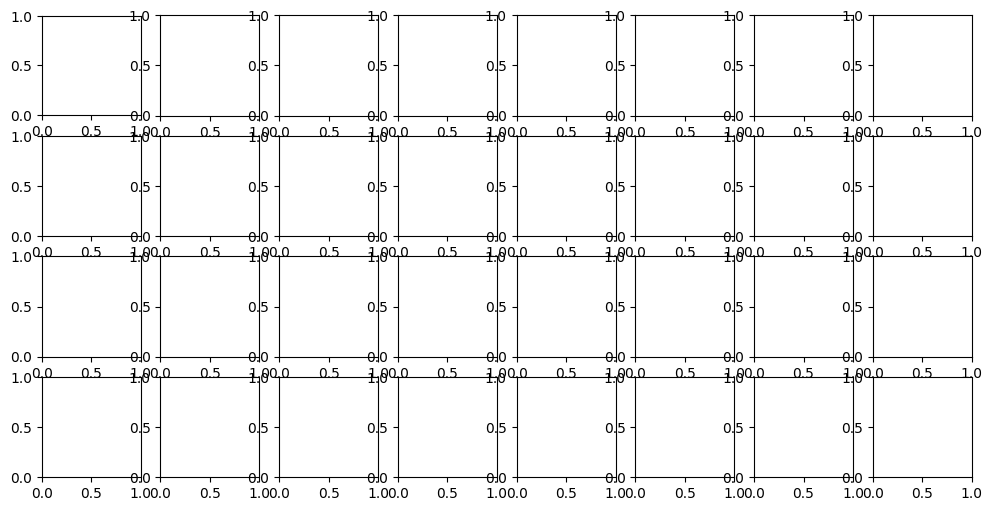

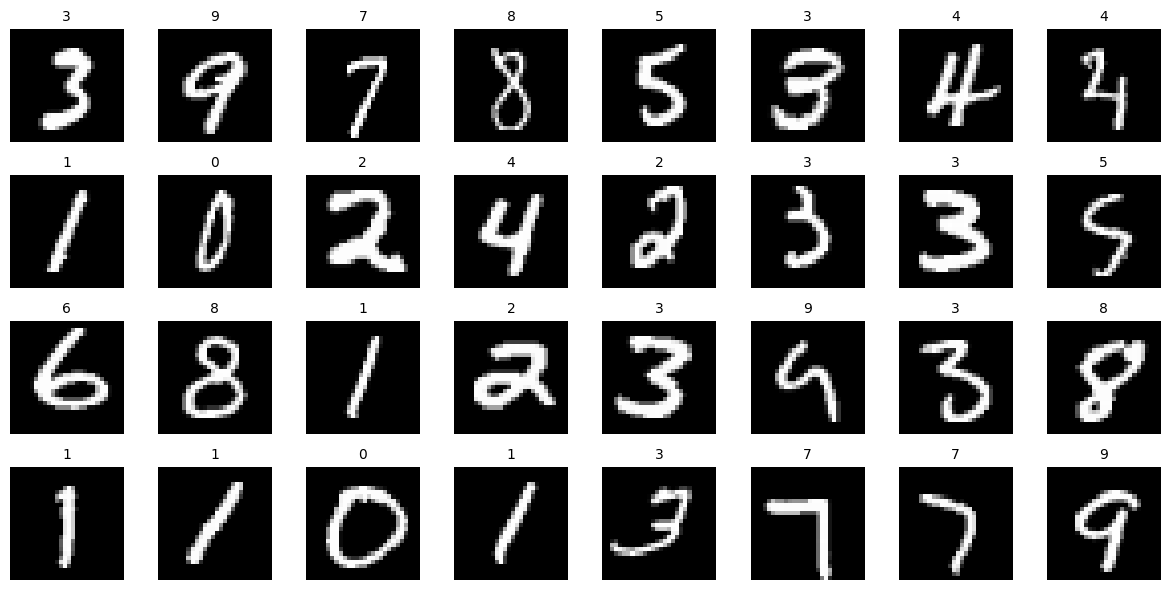

In [11]:
import numpy as np
def show_batch(X, y, rows = 4,cols = 8):
    fig, axes = plt.subplots(rows, cols, figsize = (cols * 1.5, rows * 1.5))   # 创建画布
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[i].squeeze(), cmap = 'gray')
        ax.set_title(str(y[i].item()), fontsize = 10)
        ax.axis('off')      # 关闭子图坐标轴、刻度，画面整洁
    plt.tight_layout()      # 自动调整子图间距，防止标题重叠
    plt.show()
X, y = next(iter(train_loader))   # iter() 拿迭代器，next() 取第一个 batch
show_batch(X, y)

要点：
- next(iter(train_loader)) 是"只取一个 batch 看看"的标准姿势，不需要 for 循环 break。
- X[i].squeeze() 把 (1,28,28) 的通道维去掉变 (28,28) 才能 imshow——灰度图单通道 matplotlib 不认，不 squeeze 会报错或画成 1 像素高。

fig, axes = plt.subplots(rows, cols, figsize = (cols * 1.5, rows * 1.5))
- 创建了一张 figsize 为 （8 * 1.5） * （4 * 1.5） 的画布；画布内部网格：4 行，8 列 → 32 块小画板
- 把所有这些小格子（ax 对象）打包放进一个 numpy 数组，这个数组名字叫 `axes`
- 一次性返回两个东西，用元组解包，左边 `fig` 接收画布，`axes` 接收小画板数组

axes.flat
- 把 4 行 8 列网格拉直成一条序列，方便单层 for 循环

`enumerate( )`
- `enumerate(可迭代对象)` 会在遍历的时候，**自动生成一个序号 i**。
- 每一轮循环返回一对值：`(序号, 元素)`。

ax.imshow(X[i].squeeze(), cmap = 'gray')
- `X`：整个批次张量 `[64, 1, 28, 28]`
- `X[i]`：取出批次里面**第 i 张图片** → shape `[1, 28, 28]`
- `.squeeze()`：删掉通道维度大小为 1 的维度 → `[28, 28]`，变成二维灰度矩阵
- `ax.imshow(...)`：**在当前这块小画板 ax 上面画出这张手写数字图片**
- `cmap='gray'`：灰度配色

ax.set_title(str(y[i].item()), fontsize = 10)
- `y[i]`：第 i 张图片对应的标签张量，例如 `tensor(5)`
- `.item()`：从张量中取出普通 Python 数字 `5`
- `str(...)`：转成字符串 `"5"`
- `ax.set_title("5")`：**在这块小画板上方写上标题数字 5**
- `fontsize=10`：标题文字字号

调用关系完整链路
~~~
plt.subplots(rows, cols)
    ↓
创建顶层画布 fig
创建 rows×cols 张子绘图区域，打包进axes二维数组
    ↓
axes.flat 展平一维
循环取出每一个 ax
    ↓
ax.imshow()       在这张小画布上画图
ax.set_title()    在这张小画布上加标题
ax.axis('off')    关闭这张小画布坐标轴
    ↓
plt.tight_layout() 自动调整fig里面所有子图间距
plt.show()          渲染整张fig画布
~~~

## 5.（进阶）：自定义 Dataset 处理"自己的数据"——CSV 表格

In [13]:
import pandas as pd
from sklearn.datasets import load_diabetes

# 造一个真实 CSV 场景：糖尿病数据集（442 样本 × 10 特征）
data = load_diabetes()
df = pd.DataFrame(data.data, columns = data.feature_names)   # 把特征数组转为 pandas DataFrame 表格
df['target'] = data.target    # 新增一列 target，作为回归任务的预测标签；此时整张表格一共 11 列：10 特征 + 1 标签
df.to_csv('./diabetes.csv', index = False)

class CSVRegressionDataset(Dataset):
    """读 CSV 表格数据的标准写法——单细胞表达矩阵也是这种形态"""
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)   # 读取 csv 表格到内存，存为 DataFrame 对象
        self.X = torch.tensor(self.df.iloc[:, :-1].values, dtype = torch.float32)
        self.y = torch.tensor(self.df['target'].values, dtype = torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 实例化数据集，DataLoader 加载
ds = CSVRegressionDataset('./diabetes.csv')
loader = DataLoader(ds, batch_size = 32, shuffle = True)
Xb, yb = next(iter(loader))
print(f'表格数据 batch: X{Xb.shape} y{yb.shape}')
import os; os.remove('./diabetes.csv')  # 清理临时文件

表格数据 batch: Xtorch.Size([32, 10]) ytorch.Size([32, 1])


要点：
- 表格数据在 __init__ 里一次性读进来转成 tensor，__getitem__ 只做切片——因为 CSV 读取是磁盘 IO，放在 __getitem__ 里会每取一个样本读一次文件，训练慢 100 倍。
- 标签 reshape(-1, 1)：PyTorch 回归 loss（MSELoss）要求 (N,1) 而不是 (N,)，形状不匹配会报维度错误。
- 这个模式就是你将来读单细胞表达矩阵（pd.read_csv 后转 tensor）的雏形——换数据不换代码。

`load_diabetes()` 是 sklearn 内置回归数据集：
- 样本总数：442
- 特征数量：10 项生理特征
- `data.data`：numpy 数组 `(442, 10)`，特征矩阵
- `data.target`：一维 numpy 数组 `(442,)`，疾病指标（回归标签，连续浮点数）
- `data.feature_names`：10 个特征的列名字符串列表

self.X = torch.tensor(self.df.iloc[:, :-1].values, dtype = torch.float32)
-  `iloc[:, :-1]`
   - `:` →选取**所有行（全部样本）**
   - `:-1` →选取所有列，**除了最后一列**。最后一列是标签`target`，剩下全部是特征。
-  `.values`：把 pandas DataFrame → numpy 数组，形状 `(442, 10)`
-  `torch.tensor(...)` numpy 数组转为 PyTorch 张量
-  `dtype=torch.float32`：深度学习网络参数默认 float32；**回归任务绝对不要用整数类型**。
- 最终 `self.X.shape = torch.Size([442, 10])`

self.y = torch.tensor(self.df['target'].values, dtype = torch.float32).reshape(-1, 1)
-  `self.df['target'].values`：取出标签列，得到一维 numpy 数组 `shape (442,)`
-  `.reshape(-1, 1)`
   - `-1`：自动推算第一维长度（等于样本数 442）
   - `1`：第二维 = 1，标签变成二维张量
   - 变换前：一维：`[442,]`
   - 变换后：二维：`[442, 1]`

为什么回归标签必须 reshape (-1, 1)？
- PyTorch 全连接层、损失函数 `nn.MSELoss` 要求**预测输出与标签维度严格匹配**。
- 假设网络输出：`y_hat.shape = [32, 1]`（batch_size=32，回归输出 1 维）
- 如果标签 `yb` 形状是一维 `[32]`：维度不匹配，会触发广播，计算出错误损失值，训练异常！
- reshape 后标签：`[32, 1]` 和输出维度完全一致。

完整数据流链路
~~~
磁盘 diabetes.csv → pd.read_csv() → df(442,11)
→ 拆分特征X(442,10) /标签 y(442,1)
→ __getitem__(idx) 返回单样本 (X[idx], y[idx])
→ DataLoader收集所有单样本，自动堆叠
→ batch Xb: [32, 10] , yb: [32, 1]
~~~

# 测试小结

1.Dataset 和 DataLoader 是什么关系？各自负责什么？为什么 torchvision.datasets.MNIST 能直接丢给 DataLoader？
- Dataset 定义"样本怎么存、怎么按索引取单个样本"（数据侧），DataLoader 定义"怎么把样本拼成 batch、打乱、多进程取数"（取数侧），二者是组合关系；torchvision.datasets.MNIST 本身就是一个 Dataset 子类，所以可以直接丢给 DataLoader

2.自定义 Dataset 子类必须实现哪两个方法？如果只实现一个，DataLoader 会在什么时候、以什么方式报错？
- __len__() 和 __getitem__();如果只实现 __len__() 报错发生在取数据时：ds[0] 会调用基类默认的 __getitem__，抛 NotImplementedError。;如果只实现  __getitem__() 时会在迭代数据时报错，获取不到总共的实例数，调 len(ds) 触发 NotImplementedError

3.transform 为什么必须放在 __getitem__ 里做，而不是在 __init__ 里对整个数据集一次性做完？
- 增强随机性，在每一轮 epoch 都能得到新的样本的数据变换；如果 __init__ 里一次性 transform，整个增强后的数据集会常驻内存（副本翻倍），且随机增强彻底失效（只做一次）。放 __getitem__ 是"用时才变换"，内存省、每 epoch 都重新变换。

4.训练集为什么必须 shuffle=True？如果 MNIST 按标签顺序排列且不 shuffle，模型具体会学到什么"捷径"？
- 训练必须打乱，否则每个 epoch 内类别顺序固定，模型学到"顺序"而非"特征"

5.drop_last=True 和 False 分别该用于训练还是验证？理由是什么？
- True 用于训练，方便训练且会因为不完整 batch 会让 BN 的统计量（均值和方差）偏离真实分布，且 loss 曲线最后一个点噪声大；False 用于验证，验证时不能丢失任何一个样本，会影响测试结果

6.num_workers 在 WSL 和 Windows 原生环境下的差异是什么？为什么 Windows 原生要设 0？
- WSL2 底层是 Linux，使用 fork 创建子进程，子进程继承父进程内存，多进程加载安全，可以设置 num_workers>0；
- Windows 没有 fork，只能使用 spawn，子进程会重新运行整个脚本、需要序列化数据集，极易出现死锁和序列化报错，所以 num_workers 要设为 0，只用主进程加载数据。

7.表格数据（CSV）为什么要在 __init__ 里一次性 pd.read_csv 并转成 tensor，而不是在 __getitem__ 里读？
- CSV 文本文件不支持高效随机按行读取，在`__getitem__`中读取行会造成大量重复磁盘 IO，训练速度极慢。因此小型 CSV 数据集在`__init__`一次性把整张表格读入内存，转换成张量，之后`__getitem__`只需从内存按下标取值，没有磁盘开销，速度很快。

8.回归任务的标签为什么要 reshape(-1, 1)？不 reshape 直接丢给 MSELoss 会发生什么？
- pred 是 (N,1)，y 是 (N,)，广播后两者变成 (N,N)——相当于每个样本跟所有样本都算了一遍差再取平均，损失数值是错的，梯度也是错的。所以不是"结果变了一点"，是整个训练目标都错了，模型可能直接不收敛

9.现在有一个单细胞表达矩阵：cells.csv（5000 细胞 × 20000 基因，float 数值），每行末尾一列是细胞类型标签（字符串，如 'T cell'）。要把它包装成 Dataset 供分类模型使用，标签列怎么处理？写出你的思路（不需要完整代码，说清标签编码方式和 Dataset 结构即可）。
- cells.csv：5000 行 = 5000 个细胞；前 20000 列 = 基因表达特征；最后一列字符串标签：

10.DataLoader(batch_size=64) 迭代时，如果数据集有 1000 个样本，shuffle=True 下你预期会迭代出多少个 batch？每个 batch 的 X 形状是什么？最后一轮有什么特殊情况？（假设 drop_last=False）
- 16个 batch; （64，单个样本特征维度），最后一轮为（40，单个样本特征维度）